In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/ai-2-deep-learning-for-nlp-homework-1/sample_submission.csv
/kaggle/input/ai-2-deep-learning-for-nlp-homework-1/train_dataset.csv
/kaggle/input/ai-2-deep-learning-for-nlp-homework-1/test_dataset.csv
/kaggle/input/ai-2-deep-learning-for-nlp-homework-1/val_dataset.csv


---
# Libraries
---

In [2]:

###
### SDI2100172 Georgios Skouras 
###

import pandas as pd  # For handling datasets
import numpy as np  # For numerical operations
import os  # To check dataset files
import re  # For text cleaning
import nltk  # Natural Language Toolkit for text processing
import string 
import unicodedata
import random
import emoji
import html
import seaborn as sns
random_state = random.randint(0, 1000000)  # Generate a new random seed each time

from nltk.corpus import stopwords  # Stopword removal
from nltk.tokenize import word_tokenize  # Tokenization
from nltk.stem import WordNetLemmatizer  # Lemmatization
from nltk.corpus import names
import matplotlib.pyplot as plt

from wordcloud import WordCloud
from collections import Counter

from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import learning_curve
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.feature_extraction.text import TfidfVectorizer  # TF-IDF transformation
from sklearn.model_selection import train_test_split  # Splitting data
from sklearn.linear_model import LogisticRegression  # Model
from sklearn.metrics import classification_report  # Evaluation
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
nltk.data.path.append('/root/nltk_data')
# Download required resources
#nltk.download('stopwords')
nltk.download('punkt')
nltk.download('names')


print(nltk.data.path)
nltk.data.path.append('/kaggle/working/nltk_data')



###
### SDI2100172 Georgios Skouras 
###

[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package names to /usr/share/nltk_data...
[nltk_data]   Package names is already up-to-date!
['/root/nltk_data', '/usr/share/nltk_data', '/usr/local/share/nltk_data', '/usr/lib/nltk_data', '/usr/local/lib/nltk_data', '/root/nltk_data']


--- 
# Loading the dataset
---

In [3]:
# Load the datasets
train_df = pd.read_csv('/kaggle/input/ai-2-deep-learning-for-nlp-homework-1/train_dataset.csv')
val_df = pd.read_csv('/kaggle/input/ai-2-deep-learning-for-nlp-homework-1/val_dataset.csv')
test_df = pd.read_csv('/kaggle/input/ai-2-deep-learning-for-nlp-homework-1/test_dataset.csv')

# Display the first few rows of the training dataset
train_df.head(50)

,ID,Text,Label
0,189385,@whoisralphie dude I'm so bummed ur leaving!,0
1,58036,"oh my god, a severed foot was foun in a wheely...",0
2,190139,I end up &quot;dog dialing&quot; sumtimes. Wha...,1
3,99313,@_rachelx meeeee toooooo!,0
4,157825,"I was hoping I could stay home and work today,...",0
5,130560,says plurk karma finally reached the 50s. stil...,0
6,121871,"Good to hear it @Arth This is a bit more, but ...",1
7,86813,@davorg in that case im gonna start tweeting a...,1
8,197517,"@belunyc its alright love, how are you?",1
9,6937,@brightondoll haha that has to be the best ana...,1


---
# EDA
---

In [4]:
def generate_wordcloud(df):
    text_data = ' '.join(df["Text"])  # Join all text into one string
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text_data)

    # Display the word cloud
    plt.figure(figsize=(10, 6))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')  # Turn off axis
    plt.title('Word Cloud for Text Data')
    plt.show
    

    
def plot_token_frequency(df):
    all_text = ' '.join(df["Text"])  # Join all text into one string
    tokens = word_tokenize(all_text)

    # Remove stopwords and non-alphabetic tokens
    stop_words = set(stopwords.words('english'))
    tokens = [word for word in tokens if word.lower() not in stop_words and word.isalpha()]

    # Calculate token frequencies
    token_frequencies = Counter(tokens)

    # Get the most common 20 tokens
    common_tokens = token_frequencies.most_common(20)

    # Extract words and frequencies
    words, frequencies = zip(*common_tokens)

    # Plot the token frequencies as a bar chart
    plt.figure(figsize=(12, 6))
    plt.bar(words, frequencies, color='skyblue')
    plt.xticks(rotation=45)
    plt.xlabel('Tokens')
    plt.ylabel('Frequency')
    plt.title('Top 20 Tokens Frequency')
    plt.show()
    #print(common_tokens)

def plot_text_length_distribution(df, column='Text'):
    pd.option_context('mode.use_inf_as_na', True)
    # Calculate the number of words in each text entry
    text_lengths = df[column].apply(lambda x: len(x.split()))
    
    plt.figure(figsize=(10, 5))
    sns.histplot(text_lengths, bins=50, kde=True, color="blue")
    plt.title("Text Length Distribution")
    plt.xlabel("Number of Words")
    plt.ylabel("Frequency")
    plt.show()


Dataset: Training Set
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148388 entries, 0 to 148387
Data columns (total 3 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   ID      148388 non-null  int64 
 1   Text    148388 non-null  object
 2   Label   148388 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 3.4+ MB
None
                  ID          Label
count  148388.000000  148388.000000
mean   106024.578699       0.500013
std     61150.300085       0.500002
min         0.000000       0.000000
25%     53237.500000       0.000000
50%    105998.000000       1.000000
75%    158927.250000       1.000000
max    211981.000000       1.000000

Missing Values:
 ID       0
Text     0
Label    0
dtype: int64
--------------------------------------------------
Dataset: Validation Set
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42396 entries, 0 to 42395
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------

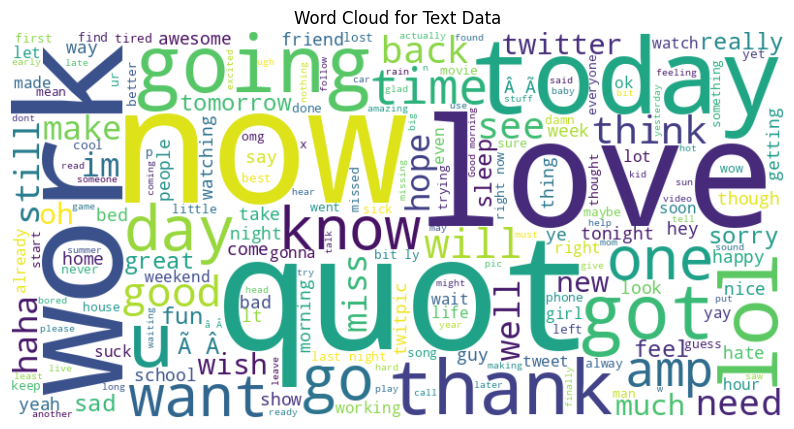

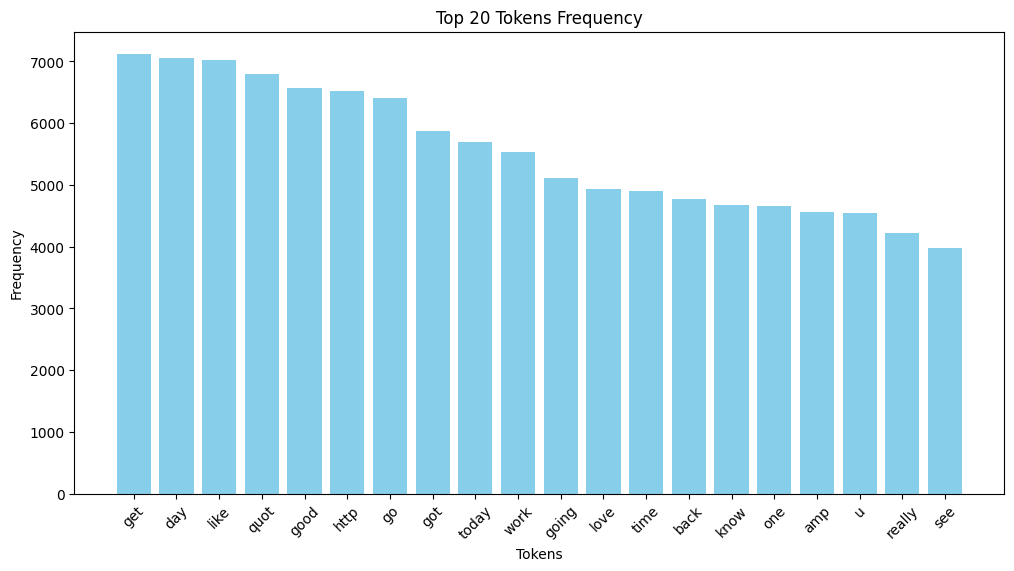

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


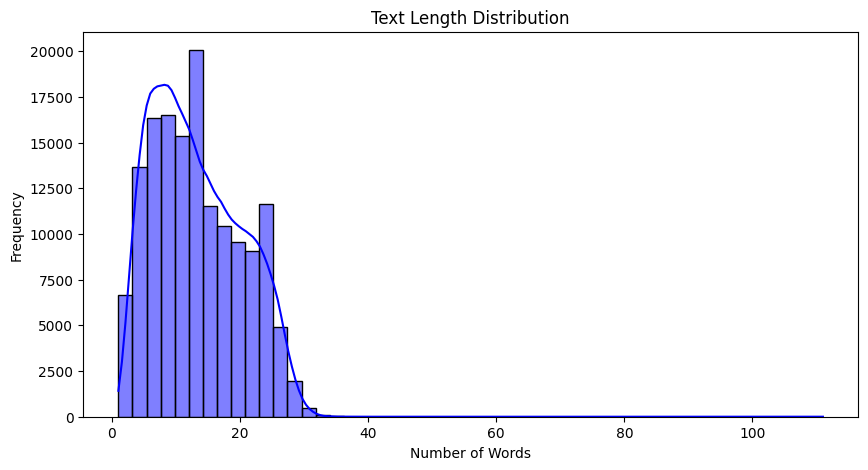

In [5]:
# Display basic dataset information
def basic_eda(df, name):
    print(f"Dataset: {name}")
    print(df.info())  # Overview of dataset
    print(df.describe())  # Statistical summary of numerical data
    print("\nMissing Values:\n", df.isnull().sum())  # Check for missing values
    print("-" * 50)

# Check for missing values and dataset statistics
basic_eda(train_df, "Training Set")
basic_eda(val_df, "Validation Set")
basic_eda(test_df, "Test Set")

generate_wordcloud(train_df) 
plot_token_frequency(train_df)
plot_text_length_distribution(train_df)



---
# Pre Proccesing
---

0                                                                                                                                                              <USER> dude i am so bummed your leaving <EXCLAMATION>
1               oh my god, a severed foot was foun in a wheely bin in cobham <EXCLAMATION> <EXCLAMATION> <EXCLAMATION> where they found is literally minutes from my house <EXCLAMATION> feel sick now <EXCLAMATION>
2    i end up <QUOTE> dog dialing <QUOTE> sumtimes <PERIOD> what's dog dialing, you ask <QUESTION> my dogs will walk across my phone & end up calling someone <PERIOD> aka <QUOTE> dog dialing <QUOTE> <EXCLAMATION>
3                                                                                                                                                                                         <USER> me to <EXCLAMATION>
4                                                                                                                i was hoping i could stay home and 

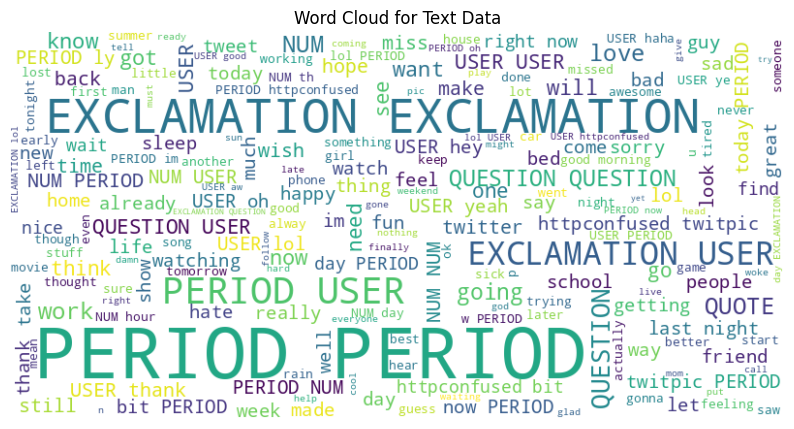

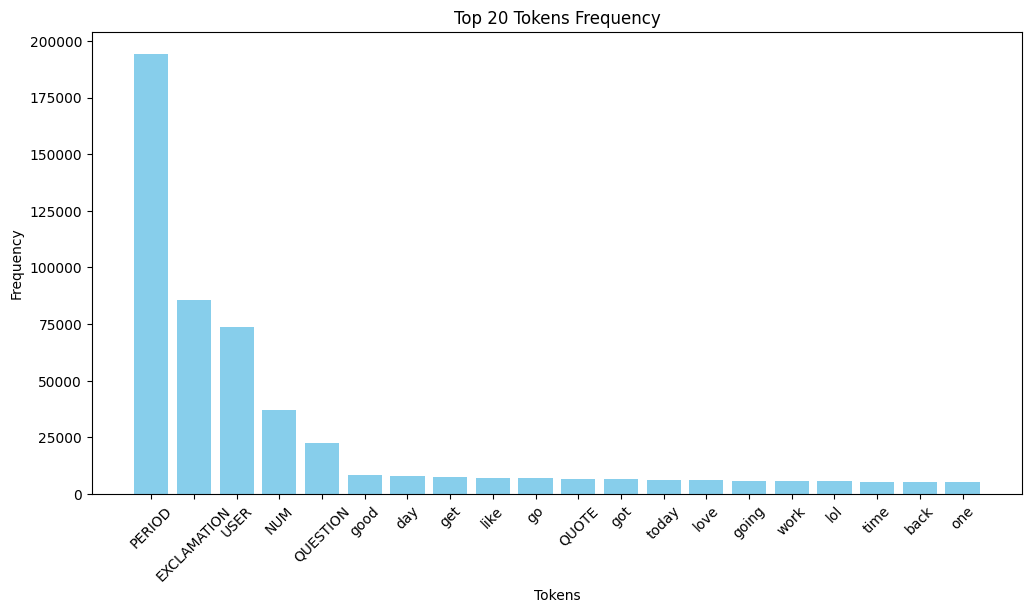

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


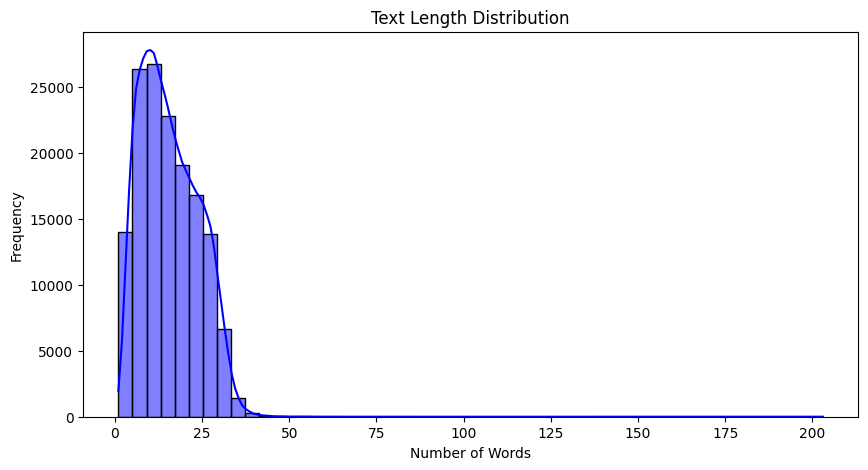

In [6]:

#stop_words = set(stopwords.words('english'))
name_list = set(names.words())

contractions = {
    "i'm": "i am", "you're": "you are", "he's": "he is", "she's": "she is", 
    "it's": "it is", "we're": "we are", "they're": "they are", "i've": "i have",
    "you've": "you have", "we've": "we have", "they've": "they have", 
    "i'd": "i would", "you'd": "you would", "he'd": "he would", "she'd": "she would",
    "we'd": "we would", "they'd": "they would", "can't": "cannot", "won't": "will not", 
    "don't": "do not", "doesn't": "does not", "didn't": "did not", "wasn't": "was not", 
    "weren't": "were not", "isn't": "is not", "aren't": "are not", "haven't": "have not", 
    "hasn't": "has not", "hadn't": "had not"
}

abbreviations = {
    "u": "you", "ur": "your", "r": "are", "pls": "please", "thx": "thanks",
    "k": "okay","y": "why"
}

emoticon_dict = {
    ":)": "happy",    
    ":D": "laughing",    
    ";)": "wink",    
    ":(": "sad",    
    ":/": "confused",    
    ":|": "neutral",    
    ":'(": "crying",    
    ":o": "surprised",    
    ":O": "shocked",    
}

#Replace common emoticons with their descriptive meanings.
def preprocess_emojis(text):
    
    for emoticon, meaning in emoticon_dict.items():
        text = re.sub(re.escape(emoticon), meaning, text)
    return text


# Function to expand contractions compactly
def expand_contractions(text):
    return re.sub(r'\b(' + '|'.join(contractions.keys()) + r')\b', lambda x: contractions[x.group(0).lower()], text)

# Function to expand abbreviations compactly
def expand_abbreviations(text):
    return re.sub(r'\b(' + '|'.join(abbreviations.keys()) + r')\b', lambda x: abbreviations[x.group(0)], text)


#conver some punctation to show meaning 
def convert_punctuation(text):
    text = text.replace("!", " <EXCLAMATION> ")
    text = text.replace("?", " <QUESTION> ")
    text = text.replace(".", " <PERIOD> ")  
    text = text.replace('"', " <QUOTE> ")
    
    
    return text

def replace_numbers(text):
    return re.sub(r'\b\d+\b', '<NUM>', text)  # Replaces only standalone numbers


def preprocess_text(text):
    # Convert to lowercase
    text = text.lower()
    text = html.unescape(text)
    # funtions for replacing 
    text = expand_contractions(text)
    text = expand_abbreviations(text)
    text = preprocess_emojis(text)
    
    # Replace emails with "Email"
    text = re.sub(r'\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Z|a-z]{2,}\b', '<EMAIL>', text)


    text = convert_punctuation(text)
    # Replace URLs with "Url_link"
    text = re.sub(r'https?://\S+|www\.\S+', '<URL_LINK>', text)

    text = re.sub(r'@\w+', '<USER>', text)  # Replace all @mentions with "USER"

    # Reduce sequences of repeated characters to a maximum of 2 (or 1)
    text = re.sub(r'(.)\1{2,}', r'\1', text)

    # Replace standalone numbers with "Num"
    text = re.sub(r'\d+', '<NUM>', text)
    
    text = unicodedata.normalize('NFKD', text).encode('ascii', 'ignore').decode('utf-8', 'ignore')

    
    text = re.sub(r'\s+', ' ', text).strip() # remove extra spaces
   
    
    return text
    


# Apply preprocessing
train_df["Text"] = train_df["Text"].apply(preprocess_text)
val_df["Text"] = val_df["Text"].apply(preprocess_text)
test_df["Text"] = test_df["Text"].apply(preprocess_text)

# Check results (only for diplaying purposes)
pd.set_option('display.max_colwidth', None)
print(train_df["Text"].head(10))

#----------------------------------------
#------not working / or reducing accuracy 
    #text = text.translate(str.maketrans("", "", string.punctuation))  # Remove punctuation
    # Tokenize the text
    #words = word_tokenize(text)
    # Filter out punctuation and stopwords
    # Replace names with "X"
    #words = ['<MENTIONED>' if word.capitalize() in name_list else word for word in words]
    
#----------------------------------------

generate_wordcloud(train_df) 
plot_token_frequency(train_df)
plot_text_length_distribution(train_df)





In [7]:
def plot_roc_curve(model, X_val, y_val):
    """
    Plots a visually enhanced ROC Curve.
    The ROC curve shows the trade-off between the True Positive Rate and False Positive Rate.
    The AUC (Area Under the Curve) is also displayed in the legend.
    """
    # Get predicted probabilities for the positive class.
    y_pred_proba = model.predict_proba(X_val)[:, 1]

    # Calculate false positive rate and true positive rate.
    fpr, tpr, thresholds = roc_curve(y_val, y_pred_proba)
    roc_auc = auc(fpr, tpr)

    # Create the plot.
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='#1f77b4', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
    plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--', label='Random Chance')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=12)
    plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=14)
    plt.legend(loc="lower right", fontsize=12)
    plt.grid(alpha=0.3)
    plt.show()

def plot_learning_curve(model, X_train, y_train):
    """
    Plots a visually enhanced Learning Curve.
    The Learning Curve shows training and validation scores as a function of training set size,
    which helps diagnose whether the model is underfitting or overfitting.
    """
    train_sizes, train_scores, val_scores = learning_curve(model, X_train, y_train, cv=5, scoring="f1", n_jobs=-1)

    # Calculate mean and standard deviation for training and validation scores.
    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    val_mean = np.mean(val_scores, axis=1)
    val_std = np.std(val_scores, axis=1)

    # Create the plot.
    plt.figure(figsize=(8, 6))
    plt.plot(train_sizes, train_mean, 'o-', color='#2ca02c', label="Training Score")
    plt.plot(train_sizes, val_mean, 'o-', color='#d62728', label="Validation Score")
    plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='#2ca02c')
    plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.1, color='#d62728')
    plt.xlabel("Training Set Size", fontsize=12)
    plt.ylabel("F1 Score", fontsize=12)
    plt.title("Learning Curve", fontsize=14)
    plt.legend(loc="best", fontsize=12)
    plt.grid(alpha=0.3)
    plt.show()


def plot_confusion_matrix(model, X_val, y_val):
    """
    Plots a visually enhanced Confusion Matrix.
    The Confusion Matrix displays the counts of True Positives, True Negatives, False Positives, and False Negatives.
    """
    y_pred = model.predict(X_val)
    cm = confusion_matrix(y_val, y_pred)
    
    # Use seaborn heatmap for improved aesthetics.
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, linewidths=1, linecolor='black')
    plt.xlabel("Predicted Label", fontsize=12)
    plt.ylabel("True Label", fontsize=12)
    plt.title("Confusion Matrix", fontsize=14)
    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)
    plt.show()

---
# TF-IDF and Logistic Regression
---

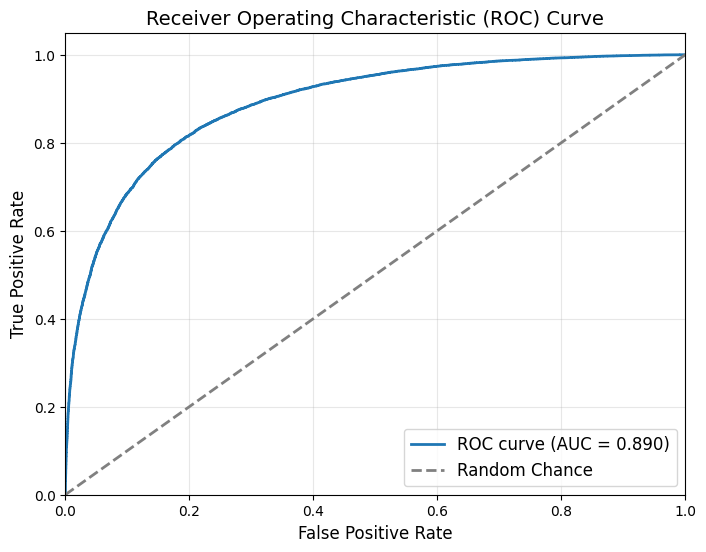

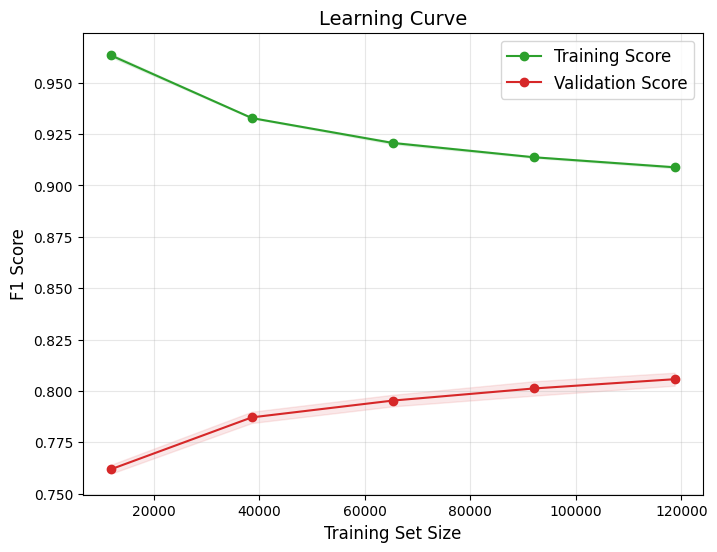

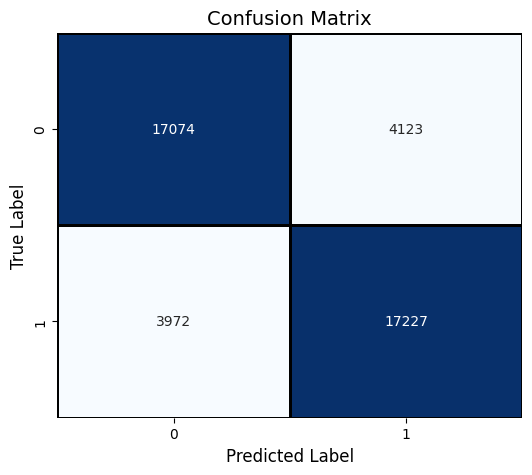

In [8]:
#-------------------------------------------
#full_text = pd.concat([train_df["Text"], val_df["Text"]])
#full_label = pd.concat([train_df["Label"], val_df["Label"]])                       #Used to expand the dataset to improve accuracy for the validation
#X_full = vectorizer.fit_transform(full_text)  # Fit + Transform on full dataset    #And the final test (It doesnt run if you just uncomment
#y_full = full_label                                                                #you have to modify it)
#plot_roc_curve(model, X_full, full_label)
#plot_learning_curve(model, X_full, full_label)
#plot_confusion_matrix(model, X_full, full_label)
#------------------------------------------


# Initialize TF-IDF vectorizer
vectorizer = TfidfVectorizer(max_features=300000,sublinear_tf=True, ngram_range=(1,3),min_df=2, max_df=0.9,norm="l2",binary=True)

X_train = vectorizer.fit_transform(train_df["Text"])
X_val =  vectorizer.transform(val_df["Text"])
X_test = vectorizer.transform(test_df["Text"])

# Extract labels
y_train = train_df["Label"]
y_val = val_df["Label"]



# Initialize and train Logistic Regression model
model = LogisticRegression(random_state=random_state, max_iter=1000,solver="saga", C=2.0,penalty="l2")
model.fit(X_train, y_train)

#solver lbfgs , saga , liblinear , newton-cg

# Call the function for ROC Curve
plot_roc_curve(model, X_val, y_val)
# Call the function for Learning Curve
plot_learning_curve(model, X_train, y_train)
# Call the function for Confusion Matrix
plot_confusion_matrix(model, X_val, y_val)



In [9]:
# Predict on the validation set
val_predictions = model.predict(X_val)

# Compute evaluation metrics on the validation set
val_accuracy = accuracy_score(y_val, val_predictions)
val_precision = precision_score(y_val, val_predictions)
val_recall = recall_score(y_val, val_predictions)
val_f1 = f1_score(y_val, val_predictions)

print("Validation Metrics:")
print("Accuracy:", val_accuracy)
print("Precision:", val_precision)
print("Recall:", val_recall)
print("F1 Score:", val_f1)


#----------- checking the partions -----------#
# print("Training set size:", len(train_df))
# print("Validation set size:", len(val_df))
# print("Test set size:", len(test_df))

# # Check the total dataset size
# total_size = len(train_df) + len(val_df) + len(test_df)
# print("Total dataset size:", total_size)

# # Check the percentage of each partition
# print("Train ratio:", len(train_df) / total_size)
# print("Validation ratio:", len(val_df) / total_size)
# print("Test ratio:", len(test_df) / total_size)



Validation Metrics:
Accuracy: 0.8090621756769506
Precision: 0.8068852459016393
Recall: 0.8126326713524222
F1 Score: 0.8097487602528848


---
# Submission
---

In [10]:
# For test data, only transform the text since there are no labels
X_test = vectorizer.transform(test_df['Text'])

# Generate predictions for the test dataset
test_predictions = model.predict(X_test)


# Create a submission DataFrame
submission = pd.DataFrame({
    'ID': test_df['ID'],
    'Label': test_predictions
})

# Save the submission file (submission.csv)
submission.to_csv("submission.csv", index=False)
print("Submission file created.")


Submission file created.
